In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ranks vs Missing Value Rates

In [8]:
results_uni_path = "eval/metrics/uni"

MECHANISM = "mcar"
MODEL = "PatchTST"
IMPUTER = "FillBy0"

missing_rates = [0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
all_dfs = {
    m: pd.read_csv(f"{results_uni_path}/{MECHANISM}/{MODEL}/{IMPUTER}/{m}.csv") for m in missing_rates
}
print(all_dfs[0.0].columns)

Index(['file', 'Time', 'AUC-PR', 'AUC-ROC', 'VUS-PR', 'VUS-ROC', 'Standard-F1',
       'PA-F1', 'Event-based-F1', 'R-based-F1', 'Affiliation-F'],
      dtype='object')


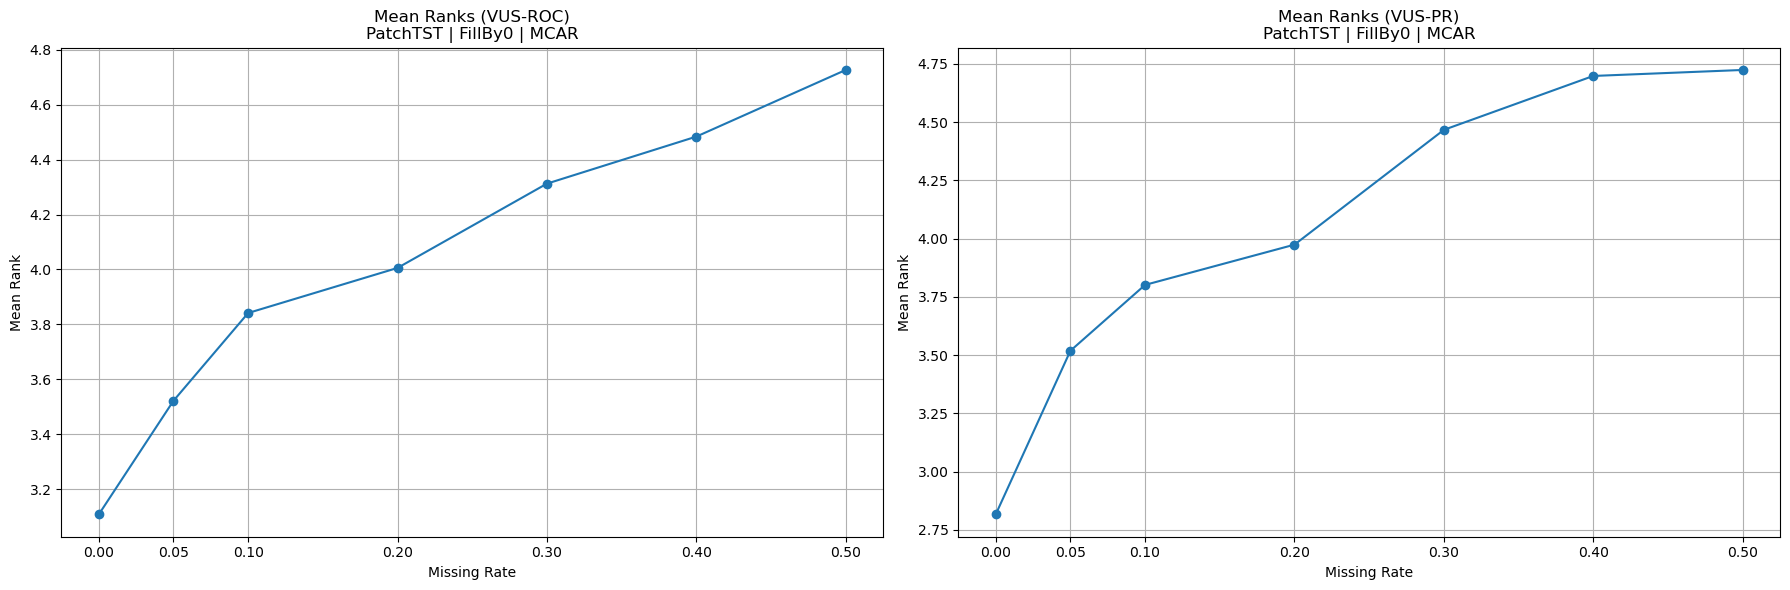

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

MECHANISM = "mcar"
MODEL = "PatchTST"
IMPUTER = "FillBy0"

for ax, metric in zip(axes, ["VUS-ROC", "VUS-PR"]):
    full_df = pd.DataFrame()
    for m in missing_rates:
        df = all_dfs[m][metric]
        df = df.rename(f"Missing rate {m}")
        full_df = pd.concat([full_df, df], axis=1)
    full_df = full_df.transpose()
    ranks = full_df.rank(ascending=False).mean(axis=1)

    ax.plot(missing_rates, ranks, marker="o")
    ax.set_title(f"Mean Ranks ({metric})\n{MODEL} | {IMPUTER} | {MECHANISM.upper()}")
    ax.set_xlabel("Missing Rate")
    ax.set_ylabel("Mean Rank")
    ax.set_xticks(missing_rates)
    ax.grid()

plt.tight_layout()
#plt.savefig(f"plots/{MECHANISM}_{MODEL}_{IMPUTER}_VUS_mean_ranks.pdf", bbox_inches='tight')
plt.show()

# Model comparison across missing values

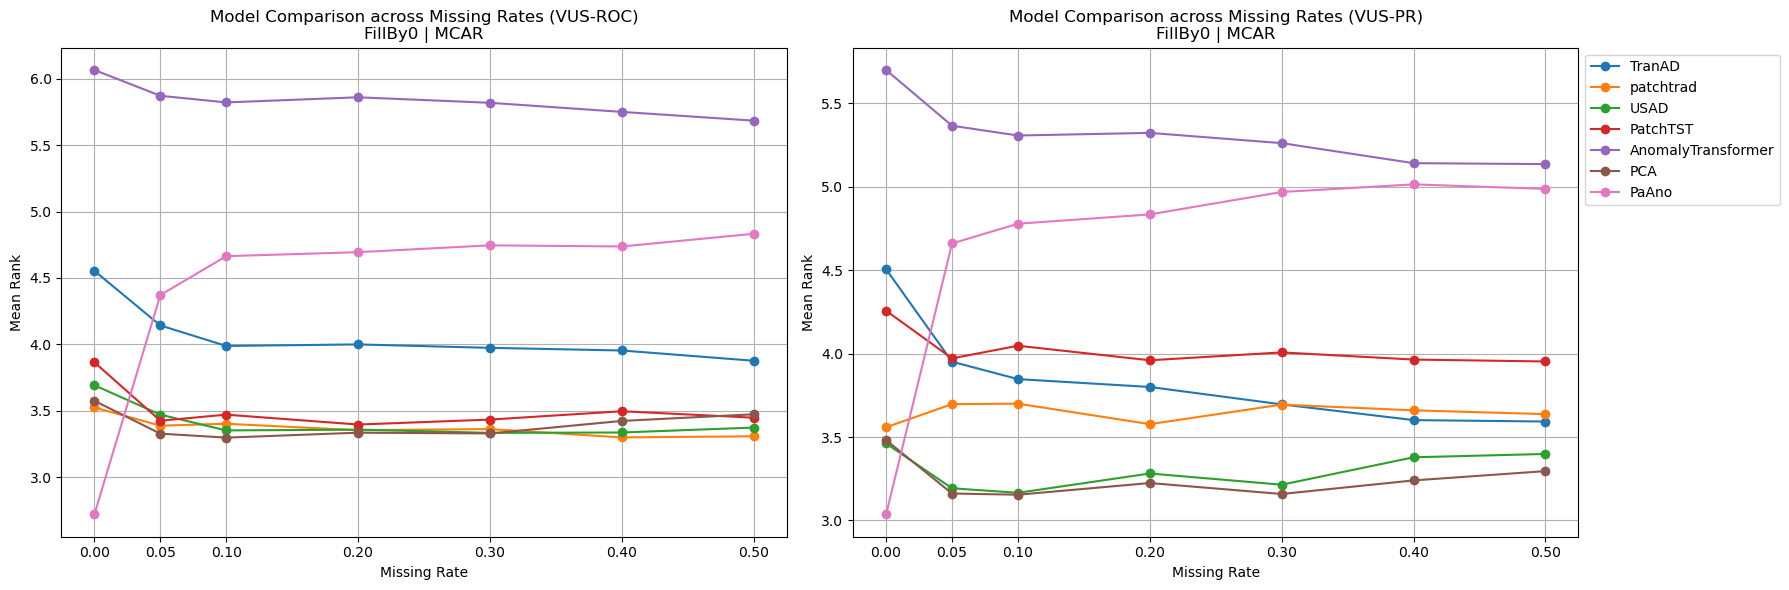

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

MECHANISM = "mcar"
MODELS = ["TranAD", "patchtrad", "USAD", "PatchTST", "AnomalyTransformer", "PCA", "PaAno"]
IMPUTER = "FillBy0"

for ax, metric in zip(axes, ["VUS-ROC", "VUS-PR"]):
    full_df = pd.DataFrame()
    for m in missing_rates:
        model_dfs = []
        for model in MODELS:
            df = pd.read_csv(f"{results_uni_path}/{MECHANISM}/{model}/{IMPUTER}/{m}.csv")
            df = df[[metric]].rename(columns={metric: model})
            model_dfs.append(df)

        ranks_df = pd.concat(model_dfs, axis=1)
        
        ranks = ranks_df.rank(ascending=False, axis=1).mean(axis=0)
        full_df = pd.concat([full_df, ranks.rename(f"Missing rate {m}")], axis=1)
    full_df = full_df.transpose()
    for model in MODELS:
        ax.plot(missing_rates, full_df[model], marker="o", label=model)
    ax.set_title(f"Model Comparison across Missing Rates ({metric})\n{IMPUTER} | {MECHANISM.upper()}")
    ax.set_xlabel("Missing Rate")
    ax.set_ylabel("Mean Rank")
    ax.set_xticks(missing_rates)
    ax.grid()
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
#plt.savefig(f"plots/{MECHANISM}_{IMPUTER}_model_comparison_VUS.pdf", bbox_inches='tight')
plt.show()  

In [11]:
ranks_df.isna().any()

TranAD                False
patchtrad             False
USAD                  False
PatchTST              False
AnomalyTransformer    False
PCA                   False
PaAno                 False
dtype: bool

# Comparisons Imputation methods

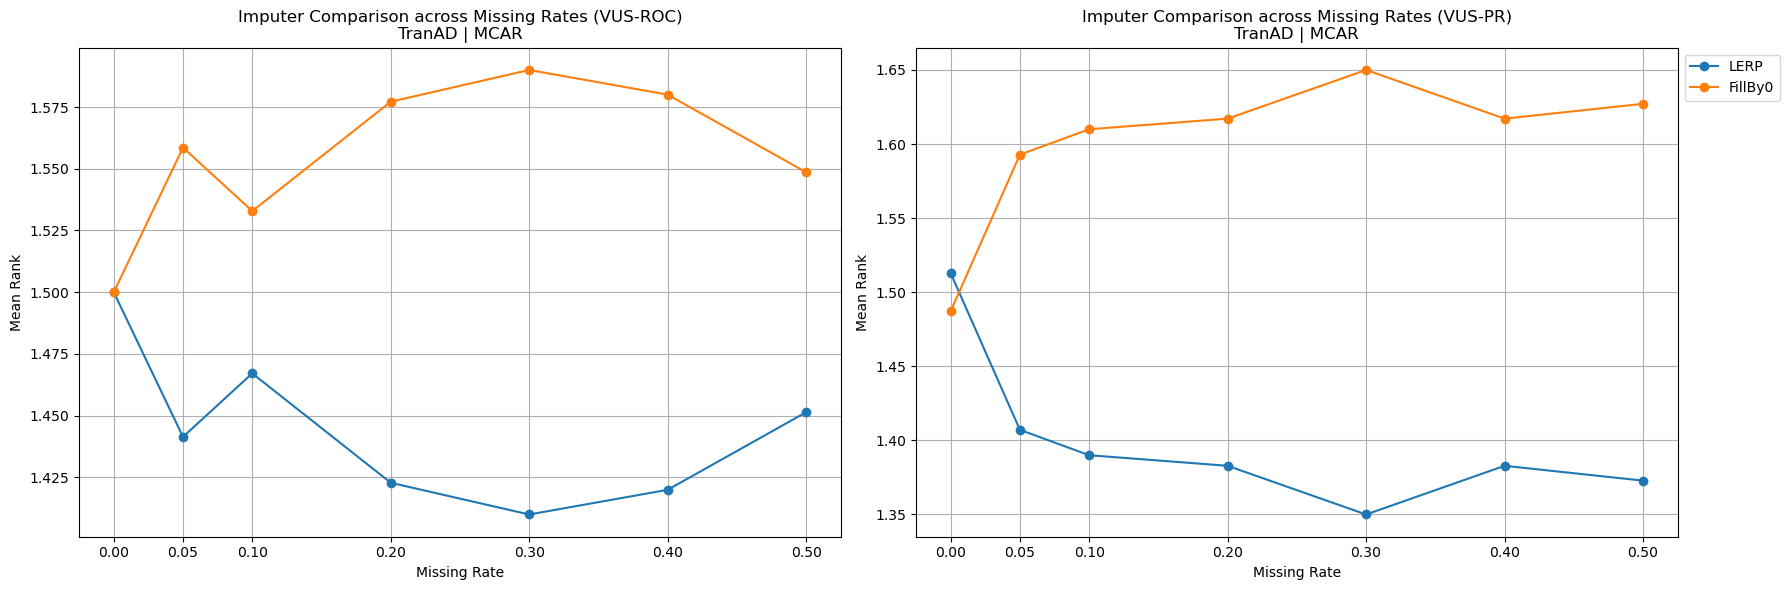

In [12]:
MODEL = "TranAD"
COMPARISON_IMPUTERS = ["LERP", "FillBy0"]
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, metric in zip(axes, ["VUS-ROC", "VUS-PR"]):
    full_df = pd.DataFrame()
    for m in missing_rates:
        imputer_dfs = []
        for imputer in COMPARISON_IMPUTERS:
            df = pd.read_csv(f"{results_uni_path}/{MECHANISM}/{MODEL}/{imputer}/{m}.csv")
            df = df[[metric]].rename(columns={metric: imputer})
            imputer_dfs.append(df)

        ranks_df = pd.concat(imputer_dfs, axis=1)
        
        ranks = ranks_df.rank(ascending=False, axis=1).mean(axis=0)
        full_df = pd.concat([full_df, ranks.rename(f"Missing rate {m}")], axis=1)
    full_df = full_df.transpose()
    for imputer in COMPARISON_IMPUTERS:
        ax.plot(missing_rates, full_df[imputer], marker="o", label=imputer)
    ax.set_title(f"Imputer Comparison across Missing Rates ({metric})\n{MODEL} | {MECHANISM.upper()}")
    ax.set_xlabel("Missing Rate")
    ax.set_ylabel("Mean Rank")
    ax.set_xticks(missing_rates)
    ax.grid()
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
#plt.savefig(f"plots/{MODEL}_{MECHANISM}_imputer_comparison_VUS.pdf", bbox_inches='tight')
plt.show()